# EfficientNetB0  - Cross-Database Deepfake Detection Experiment

**Research question:** Does an RGB-appearance detector trained on one deepfake dataset generalize to others?

**Architecture (aligned with main notebook `the_modles_fixed_new` §8):**
- EfficientNetB0 (ImageNet weights) → GAP → Dense head → sigmoid
- Stage 1: backbone frozen, train head only
- Stage 2: unfreeze top 30% of backbone, fine-tune end-to-end at low LR
- Augmentation: flips + mild brightness/contrast + pad-then-crop (real random crop, no `random_hue`)

**Experiment matrix:** 5 training runs × 5 test sets = **25 evaluations**

| Train ↓ \ Test → | OpenForensics | CustomWar | CelebDF | CiFake | ALL |
|------------------|---------------|-----------|---------|--------|-----|
| OpenForensics    | ✓ within      | ✗ cross   | ✗ cross | ✗ cross | mix |
| CustomWar        | ✗ cross       | ✓ within  | ✗ cross | ✗ cross | mix |
| CelebDF          | ✗ cross       | ✗ cross   | ✓ within | ✗ cross | mix |
| CiFake           | ✗ cross       | ✗ cross   | ✗ cross  | ✓ within | mix |
| ALL              | mix           | mix       | mix     | mix    | ✓ within |

**Databases:** OpenForensics · CustomWar · CelebDF · CiFake (CiFake uses the 80/20 split from `cifake_split/`)

In [1]:
# Cell 1
# Setup: imports, seeds, GPU, mixed precision
# GPU memory growth: prevents TF from grabbing ALL VRAM at startup,
# which then spills into CPU RAM and triggers the OOM killer.
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
import os
import gc
import glob
import random
import pickle
import numpy as np
import tensorflow as tf
import mimetypes
from datetime import datetime

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/nvidia-cuda-toolkit'
tf.config.optimizer.set_jit(False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth enabled')
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
print(f'Setup complete — TensorFlow {tf.__version__}')

2026-06-04 15:34:21.644923: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU memory growth enabled for 1 GPU(s)
GPU memory growth enabled
Setup complete — TensorFlow 2.20.0


In [2]:
# Cell 2
# Paths, model directory, TensorBoard logging helpers
GDRIVE_PATH      = os.path.expanduser('~/RealEyes/gdrive')
DATASET_ROOT     = os.path.join(GDRIVE_PATH, 'data_set_split')
DATASETS_DIR     = os.path.expanduser('~/RealEyes/RealEyes/datasets')
CELEBDF_DIR      = os.path.join(DATASETS_DIR, 'celebdf_v2')
CIFAKE_SPLIT_DIR = os.path.join(DATASETS_DIR, 'cifake_split')

MODEL_NAME            = 'efficientnet'
EXPERIMENT_MODELS_DIR = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'models', 'RealEyes_experiment')
MODEL_DIR             = os.path.join(EXPERIMENT_MODELS_DIR, MODEL_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TB_LOG_ROOT = os.path.expanduser('~/RealEyes/tensorboard_logs')
os.makedirs(TB_LOG_ROOT, exist_ok=True)


def get_tb_log_dir(train_db_name, suffix='train'):
    ts = datetime.now().strftime('%Y%m%d_%H%M')
    return os.path.join(TB_LOG_ROOT, MODEL_NAME, f'{suffix}_{train_db_name}', ts)


def log_eval_to_tb(train_db_name, test_db_name, metrics: dict, step=0):
    log_dir = os.path.join(
        TB_LOG_ROOT, MODEL_NAME, 'cross_db_eval',
        f'train_{train_db_name}__test_{test_db_name}'
    )
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, float(value), step=step)
    writer.flush()


print('Paths ready')
print(f'  MODEL_DIR        : {MODEL_DIR}')
print(f'  CIFAKE_SPLIT_DIR : {CIFAKE_SPLIT_DIR}')
print(f'  TB_LOG_ROOT      : {TB_LOG_ROOT}')
print()
print('View TensorBoard:')
print(f'  [server ] tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print( '  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>')
print( '  [browser] http://localhost:6006')

Paths ready
  MODEL_DIR        : /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet
  CIFAKE_SPLIT_DIR : /home/sceuser/RealEyes/RealEyes/datasets/cifake_split
  TB_LOG_ROOT      : /home/sceuser/RealEyes/tensorboard_logs

View TensorBoard:
  [server ] tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all
  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>
  [browser] http://localhost:6006


In [3]:
# Cell 3
# Database paths and cross-database experiment configuration
# CiFake now uses the 80/20 split (cifake_split/{train,val,test}) created
# by the main notebook's Section 3.3 — so it has a real held-out test set.

DATABASES = {}


def _try_add(name, paths):
    missing = [k for k, v in paths.items() if not os.path.isdir(v)]
    if missing:
        print(f'  {name}: missing splits {missing} — skipped')
        return
    DATABASES[name] = paths
    print(f'  {name}')


print('Scanning databases...')

_try_add('OpenForensics', {
    'train': os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Train'),
    'val':   os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Validation'),
    'test':  os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Test'),
})
_try_add('CustomWar', {
    'train': os.path.join(DATASET_ROOT, 'train'),
    'val':   os.path.join(DATASET_ROOT, 'val'),
    'test':  os.path.join(DATASET_ROOT, 'test'),
})
_try_add('CelebDF', {
    'train': os.path.join(CELEBDF_DIR, 'train'),
    'val':   os.path.join(CELEBDF_DIR, 'val'),
    'test':  os.path.join(CELEBDF_DIR, 'test'),
})
_try_add('CiFake', {
    'train': os.path.join(CIFAKE_SPLIT_DIR, 'train'),
    'val':   os.path.join(CIFAKE_SPLIT_DIR, 'val'),
    'test':  os.path.join(CIFAKE_SPLIT_DIR, 'test'),
})

print(f'\nActive databases: {list(DATABASES.keys())}')

Scanning databases...
  OpenForensics
  CustomWar
  CelebDF
  CiFake

Active databases: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake']


In [4]:
# Cell 4
# Data loading helpers (paths, labels, class weights)
# load_split() supports both real DB names and the special 'ALL' name
# (concatenation of every database's split).

def load_dataset_images(dataset_path, max_images=None):
    valid_ext = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    image_paths, labels, skipped = [], [], 0

    for folder in sorted(os.listdir(dataset_path)):
        fpath = os.path.join(dataset_path, folder)
        if not os.path.isdir(fpath):
            continue
        fu = folder.upper()
        if fu == 'FAKE':
            label = 1
        elif fu == 'REAL':
            label = 0
        else:
            print(f'  Unknown folder "{folder}" in {dataset_path} — skipped')
            continue

        collected = []
        for root, _, files in os.walk(fpath):
            for fname in files:
                if os.path.splitext(fname)[1].lower() not in valid_ext:
                    skipped += 1
                    continue
                collected.append(os.path.join(root, fname))
        if max_images:
            collected = collected[:max_images]
        image_paths.extend(collected)
        labels.extend([label] * len(collected))

    if skipped:
        print(f'  {skipped} non-image files skipped')
    return np.array(image_paths), np.array(labels)


def load_split(target_name, split='train'):
    """Load (paths, labels) for a target.

    target_name: a real DB key in DATABASES, OR the literal string 'ALL'
                 which concatenates every database's split.
    """
    if target_name == 'ALL':
        all_paths, all_labels = [], []
        for db_name in DATABASES:
            paths, labels = load_dataset_images(DATABASES[db_name][split])
            all_paths.extend(paths)
            all_labels.extend(labels)
        paths  = np.array(all_paths)
        labels = np.array(all_labels)
    else:
        paths, labels = load_dataset_images(DATABASES[target_name][split])

    n_real = int(np.sum(labels == 0))
    n_fake = int(np.sum(labels == 1))
    print(f'    {target_name}/{split}: {len(paths):,} images  (REAL={n_real:,}, FAKE={n_fake:,})')
    return paths, labels


def compute_class_weights(labels):
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    return {int(c): float(w) for c, w in zip(classes, weights)}


print('Data loading helpers ready (load_split supports ALL)')

Data loading helpers ready (load_split supports ALL)


In [ ]:
# Cell 5
# EfficientNet RGB dataset pipeline with augmentation
# Aligned with main notebook §5:
#   - Real pad-then-crop (the old random_crop with size=IMG_SIZE was a no-op)
#   - Mild brightness/contrast bounds (0.10 / 0.9-1.1)
#   - random_hue removed; saturation bounds tightened — heavy colour jitter erases
#     the very deepfake artefacts we want to detect
#   - eff_preprocess is a passthrough in tf.keras (normalization is built into the model)

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE


def _decode(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.float32)


def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.12)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    # Pad-then-crop: implicit translation and scale robustness
    h = tf.cast(IMG_SIZE[0] * 1.12, tf.int32)
    w = tf.cast(IMG_SIZE[1] * 1.12, tf.int32)
    img = tf.image.resize(img, [h, w])
    img = tf.image.random_crop(img, size=[IMG_SIZE[0], IMG_SIZE[1], 3])
    # Random 90° rotation — deepfake artifacts are rotation-invariant
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


def build_eff_dataset(image_paths, labels, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if training:
        ds = ds.shuffle(min(len(image_paths), 2000), reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (eff_preprocess(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    # Limit prefetch to 4 batches to prevent RAM exhaustion on large datasets.
    # AUTOTUNE prefetch on 300K-image datasets causes "autotune ram budget exceeded" warnings
    # and can trigger server-side OOM kills.
    ds = ds.prefetch(4)
    # Apply a 3 GB RAM budget for the autotune system on the whole pipeline
    options = tf.data.Options()
    options.autotune.ram_budget = 3 * 1024 * 1024 * 1024
    ds = ds.with_options(options)
    return ds


print('EfficientNet dataset pipeline ready (pad-then-crop, bounded prefetch=4)')

EfficientNet dataset pipeline ready (pad-then-crop, bounded prefetch=4)


In [6]:
# Cell 6
# EfficientNetB0 builder with LoRA on classification head
# Phase 1: frozen backbone; Phase 2: LoRA-only head fine-tuning.
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model
from tensorflow.keras.metrics import AUC, Precision, Recall

LORA_RANK  = 16
LORA_ALPHA = 32.0  # scale = alpha / rank = 2.0


@tf.keras.utils.register_keras_serializable(package='RealEyes')
class LoRADense(tf.keras.layers.Layer):
    """Dense layer with Low-Rank Adaptation (LoRA).

    Phase 1 (lora_only=False, default):
        Trains both the base Dense weights (kernel/bias) AND the LoRA
        adapter matrices (lora_A, lora_B).  lora_B is zero-initialised so
        the LoRA delta starts at zero — the layer behaves like a plain
        Dense layer at the beginning of training.

    Phase 2 (call set_lora_only(True) before compiling):
        Uses tf.stop_gradient on kernel/bias so they receive no gradient
        updates.  Only lora_A and lora_B are trained — parameter-efficient
        fine-tuning with a fraction of the full Dense parameter count.

    Forward pass:
        out = (W·x + b) + scale * (x · A · B)
        where W, b are frozen in Phase 2 and A, B are always trainable.
    """
    def __init__(self, units, rank=8, alpha=16.0, activation=None,
                 kernel_regularizer=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.rank       = rank
        self.alpha      = alpha
        self.scale      = float(alpha) / float(rank)
        self._act       = tf.keras.activations.get(activation)
        self._kreg      = tf.keras.regularizers.get(kernel_regularizer)
        self.use_bias   = use_bias
        self._lora_only = False  # runtime flag — not persisted to config

    def build(self, input_shape):
        d_in = int(input_shape[-1])
        # Keras 3: name must be a keyword argument (not the first positional arg)
        self.kernel = self.add_weight(
            shape=(d_in, self.units),
            initializer='glorot_uniform',
            regularizer=self._kreg,
            trainable=True,
            name='kernel')
        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
                name='bias')
        # LoRA matrices: A ~ he_normal,  B = zeros  → delta = 0 at init
        self.lora_A = self.add_weight(
            shape=(d_in, self.rank),
            initializer='he_normal',
            trainable=True,
            name='lora_A')
        self.lora_B = self.add_weight(
            shape=(self.rank, self.units),
            initializer='zeros',
            trainable=True,
            name='lora_B')
        super().build(input_shape)

    def call(self, x):
        # Phase 2: stop_gradient prevents updates to base weights
        W   = tf.stop_gradient(self.kernel) if self._lora_only else self.kernel
        out = tf.matmul(x, W)
        if self.use_bias:
            b   = tf.stop_gradient(self.bias) if self._lora_only else self.bias
            out = out + b
        # LoRA delta always gets gradients regardless of phase
        out = out + tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scale
        if self._act is not None:
            out = self._act(out)
        return out

    def set_lora_only(self, value: bool):
        """True = Phase 2: base Dense weights frozen via stop_gradient.
        Only lora_A and lora_B receive gradient updates.
        Call this BEFORE model.compile() for Stage 2 training.
        """
        self._lora_only = value

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units':              self.units,
            'rank':               self.rank,
            'alpha':              self.alpha,
            'activation':         tf.keras.activations.serialize(self._act),
            'kernel_regularizer': tf.keras.regularizers.serialize(self._kreg),
            'use_bias':           self.use_bias,
        })
        return cfg


# Helper for loading models that contain LoRADense
LORA_CUSTOM_OBJECTS = {'LoRADense': LoRADense}


def build_efficientnet_b0(train_base=False):
    """EfficientNetB0 with ImageNet weights + LoRA-enhanced classification head.

    Head:
    - BatchNormalization after GAP: stabilises activations
    - Dropout(0.20): reduced from 0.30 (original over-regularised)
    - LoRADense(256, rank=16): low-rank adaptation of the main Dense layer.
      Stage 1 trains base weights + LoRA adapters.
      Stage 2 freezes base weights, trains only LoRA (much more efficient).
    - BatchNormalization after LoRADense
    - Dropout(0.15): reduced from 0.25
    - Dense(1, sigmoid): output
    """
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3)
    )
    base.trainable = train_base
    L2 = tf.keras.regularizers.l2(1e-4)

    inputs  = layers.Input(shape=(224, 224, 3), name='rgb_input')
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D(name='gap')(x)
    x       = layers.BatchNormalization(name='bn_gap')(x)
    x       = layers.Dropout(0.20, name='drop1')(x)
    x       = LoRADense(256, rank=LORA_RANK, alpha=LORA_ALPHA,
                        activation='relu', kernel_regularizer=L2,
                        name='lora_dense1')(x)
    x       = layers.BatchNormalization(name='bn_dense1')(x)
    x       = layers.Dropout(0.15, name='drop2')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='prob_fake')(x)

    model = Model(inputs, outputs, name='EfficientNetB0_Deepfake')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
    )
    return model


print('EfficientNetB0 builder ready  (LoRA head: rank={}, alpha={})'.format(LORA_RANK, LORA_ALPHA))
_tmp  = build_efficientnet_b0()
total = _tmp.count_params()
lora_params = sum(
    p.numpy().size
    for lyr in _tmp.layers if isinstance(lyr, LoRADense)
    for p in [lyr.lora_A, lyr.lora_B]
)
print(f'  Total parameters:   {total:,}')
print(f'  LoRA-only params:   {lora_params:,}  (Stage 2 trains only these + BN + output)')
del _tmp
tf.keras.backend.clear_session()

EfficientNetB0 builder ready  (LoRA head: rank=16, alpha=32.0)


I0000 00:00:1780587266.340352  127188 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13775 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


  Total parameters:   4,408,484
  LoRA-only params:   24,576  (Stage 2 trains only these + BN + output)


In [7]:
# Cell 7
# Evaluation metrics and result logging helpers
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


def find_optimal_threshold(y_true, y_prob, beta=1.0):
    """Scan thresholds 0.05→0.95 and return the one that maximises F-beta on FAKE.

    beta=1 → equal precision/recall (F1).
    beta=2 → recall weighted 2× (catching fakes is more important than false alarms).
    """
    best_t, best_f = 0.50, 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (y_prob >= t).astype(int)
        tp = int(((preds == 1) & (y_true == 1)).sum())
        fp = int(((preds == 1) & (y_true == 0)).sum())
        fn = int(((preds == 0) & (y_true == 1)).sum())
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec  = tp / (tp + fn)
        fb   = (1 + beta**2) * prec * rec / (beta**2 * prec + rec)
        if fb > best_f:
            best_f, best_t = fb, float(t)
    return best_t


def smart_class_weights(labels):
    """Balanced class weights capped at 3× to prevent over-correction.

    Without capping, CelebDF (641 REAL vs 4770 FAKE) gives REAL a 4.2×
    penalty, causing the model to almost never predict FAKE.
    """
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    w_dict  = {int(c): float(w) for c, w in zip(classes, weights)}
    if len(w_dict) == 2:
        ratio = max(w_dict[0], w_dict[1]) / min(w_dict[0], w_dict[1])
        if ratio > 3.0:
            min_key = min(w_dict, key=w_dict.get)
            max_key = 1 - min_key
            w_dict[max_key] = w_dict[min_key] * 3.0
    return w_dict


def evaluate_model(model, test_ds, threshold=0.50):
    """Returns (metrics, report, y_true, y_prob).

    threshold: use find_optimal_threshold() on the val set to compute this
               instead of relying on the default 0.5.
    """
    y_true, y_prob = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0).flatten()
        y_true.extend(y_batch.numpy())
        y_prob.extend(preds)

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=['REAL', 'FAKE'],
        output_dict=True, digits=4, zero_division=0
    )
    metrics = {
        'accuracy':       float(accuracy_score(y_true, y_pred)),
        'roc_auc':        float(roc_auc_score(y_true, y_prob)),
        'f1_fake':        float(report['FAKE']['f1-score']),
        'f1_real':        float(report['REAL']['f1-score']),
        'precision_fake': float(report['FAKE']['precision']),
        'recall_fake':    float(report['FAKE']['recall']),
        'threshold':      float(threshold),
    }
    return metrics, report, y_true, y_prob


def print_eval_report(train_db, test_db, metrics, report):
    if train_db == test_db:
        tag = '  [WITHIN]   '
    elif train_db == 'ALL' or test_db == 'ALL':
        tag = '  [ALL-MIX]  '
    else:
        tag = '  [CROSS]    '
    print(f'\n{tag}Trained on {train_db:<15} → Tested on {test_db}')
    sep = '  ' + '-' * 58
    print(sep)
    for cls in ['REAL', 'FAKE']:
        r = report[cls]
        print(f'  {cls:<6}  P={r["precision"]:.4f}  R={r["recall"]:.4f}  F1={r["f1-score"]:.4f}  n={int(r["support"]):,}')
    print(sep)
    print(f'  Accuracy={metrics["accuracy"]:.4f}   ROC-AUC={metrics["roc_auc"]:.4f}')


print('Evaluation helpers ready')

Evaluation helpers ready


In [8]:
# Cell 8
# Auto-backup and Google Drive sync utilities
# Keeps exactly ONE backup of the previous run — no duplicates.
# Each new run replaces the old backup and immediately syncs to Drive.
# Local:  .../models/backups/efficientnet_previous_run/
# Drive:  gdrive:deepfake_image_project/models/backups/efficientnet_previous_run
import shutil, subprocess

_BACKUP_DIR   = os.path.expanduser(
    '~/RealEyes/gdrive/deepfake_image_project/models/backups/efficientnet_previous_run')
_DRIVE_BACKUP = 'gdrive:deepfake_image_project/models/backups/efficientnet_previous_run'

if os.path.isdir(MODEL_DIR) and any(os.scandir(MODEL_DIR)):
    if os.path.isdir(_BACKUP_DIR):
        shutil.rmtree(_BACKUP_DIR)
    shutil.copytree(MODEL_DIR, _BACKUP_DIR)
    n = len(os.listdir(_BACKUP_DIR))
    print(f'Backup created locally  → {_BACKUP_DIR}  ({n} files)')

    print('Syncing backup to Google Drive...')
    r = subprocess.run(
        ['rclone', 'sync', _BACKUP_DIR, _DRIVE_BACKUP, '--stats-one-line'],
        capture_output=False, text=True)
    if r.returncode == 0:
        print(f'Backup on Drive         → {_DRIVE_BACKUP}')
    else:
        print(f'WARNING: Drive sync failed (exit {r.returncode}) — backup safe locally.')
else:
    print('No existing models to back up — starting fresh.')

del _BACKUP_DIR, _DRIVE_BACKUP

Backup created locally  → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/backups/efficientnet_previous_run  (8 files)
Syncing backup to Google Drive...
Backup on Drive         → gdrive:deepfake_image_project/models/backups/efficientnet_previous_run


In [9]:
# Cell 9
# Main cross-database training loop (5 train x 5 test)
# Resumes from checkpoints; Stage 1 head training then Stage 2 LoRA fine-tune.
import subprocess

BATCH_SIZE        = 32  # small datasets (CustomWar 7K)
BATCH_SIZE_LARGE  = 16  # large datasets (CelebDF 71K, OpenForensics 140K, ALL 298K)
BATCH_SIZE_ALL    = 16  # alias kept for clarity
TRAIN_TARGETS = list(DATABASES.keys()) + ['ALL']
TEST_TARGETS  = list(DATABASES.keys()) + ['ALL']

results_path = os.path.join(MODEL_DIR, 'all_results.pkl')
preds_path   = os.path.join(MODEL_DIR, 'all_preds.pkl')

all_results = pickle.load(open(results_path, 'rb')) if os.path.exists(results_path) else {}
all_preds   = pickle.load(open(preds_path,   'rb')) if os.path.exists(preds_path)   else {}
print(f'Loaded existing results for: {list(all_results.keys())}')

for train_target in TRAIN_TARGETS:
    print(f'\n{"="*70}')
    print(f'  EfficientNetB0 — {train_target}')
    print(f'{"="*70}')

    s1_path   = os.path.join(MODEL_DIR, f'eff_stage1_{train_target}.keras')
    best_path = os.path.join(MODEL_DIR, f'trained_on_{train_target}.keras')
    model_ready = os.path.exists(best_path)
    s1_ready    = os.path.exists(s1_path)

    if model_ready:
        print(f'  [SKIP] trained_on_{train_target}.keras already exists — skipping training.')
    else:
        print('\nLoading training data...')
        train_paths, train_lbls = load_split(train_target, 'train')
        val_paths,   val_lbls   = load_split(train_target, 'val')
        class_weights           = smart_class_weights(train_lbls)
        print(f'  Class weights: {class_weights}')

        # Use smaller batch for large datasets to avoid OOM
        LARGE_TARGETS = {'OpenForensics', 'CelebDF', 'ALL'}
        bs = BATCH_SIZE_LARGE if train_target in LARGE_TARGETS else BATCH_SIZE
        print(f'  Batch size: {bs}')
        train_ds = build_eff_dataset(train_paths, train_lbls, batch_size=bs, training=True)
        val_ds   = build_eff_dataset(val_paths,   val_lbls,   batch_size=bs, training=False)
        del train_paths, train_lbls, val_paths, val_lbls
        gc.collect()

        tb_log = get_tb_log_dir(train_target, suffix='train')

        if s1_ready:
            print(f'\n  [SKIP] Stage 1 already saved — will load in Stage 2.')
            gc.collect()
            tf.keras.backend.clear_session()
        else:
            print(f'\nStage 1 — frozen backbone ({train_target})...')
            gc.collect(); tf.keras.backend.clear_session()
            model = build_efficientnet_b0(train_base=False)
            callbacks_s1 = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_auc', mode='max', patience=10,
                    restore_best_weights=True, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_auc', mode='max', factor=0.5,
                    patience=4, min_lr=1e-6, verbose=1),
                tf.keras.callbacks.ModelCheckpoint(
                    s1_path, monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
                tf.keras.callbacks.TensorBoard(
                    log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
            ]
            try:
                model.fit(train_ds, validation_data=val_ds,
                          epochs=30, class_weight=class_weights,
                          callbacks=callbacks_s1, verbose=1)
            except Exception as _s1_err:
                import traceback
                print(f'\n!!! Stage 1 training ERROR for {train_target}: {_s1_err}')
                traceback.print_exc()
            if not os.path.exists(s1_path):
                print(f'  Stage 1 produced no checkpoint — skipping {train_target}.')
                gc.collect(); tf.keras.backend.clear_session()
                continue

        # Instead of partially unfreezing the backbone (expensive, risks
        # catastrophic forgetting), we keep the backbone fully frozen and
        # switch all LoRADense layers to lora_only mode.  Only the tiny
        # lora_A and lora_B matrices receive gradients — far fewer trainable
        # parameters, more stable fine-tuning, no backbone degradation.
        print(f'\nStage 2 — LoRA-only fine-tuning (backbone fully frozen) [{train_target}]...')
        # Release previous model from TF graph before Stage 2 load
        try:
            del model
        except NameError:
            pass
        gc.collect()
        tf.keras.backend.clear_session()
        model = tf.keras.models.load_model(s1_path, compile=False,
                                           custom_objects=LORA_CUSTOM_OBJECTS)
        model.get_layer('efficientnetb0').trainable = False
        # Activate lora_only mode on all LoRADense layers
        lora_found = []
        for lyr in model.layers:
            if isinstance(lyr, LoRADense):
                lyr.set_lora_only(True)
                lora_found.append(lyr.name)
        print(f'  LoRA layers (lora_only=True): {lora_found}')
        lora_params = sum(
            lyr.lora_A.numpy().size + lyr.lora_B.numpy().size
            for lyr in model.layers if isinstance(lyr, LoRADense)
        )
        print(f'  Stage 2 trainable LoRA params: {lora_params:,}')

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
        )
        callbacks_s2 = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=10,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc', mode='max', factor=0.5,
                patience=4, min_lr=1e-7, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                best_path, monitor='val_auc', mode='max',
                save_best_only=True, verbose=1),
            tf.keras.callbacks.TensorBoard(
                log_dir=tb_log, histogram_freq=0, update_freq='epoch'),
        ]
        try:
            model.fit(train_ds, validation_data=val_ds,
                      epochs=30, class_weight=class_weights,
                      callbacks=callbacks_s2, verbose=1)
        except Exception as _fit_err:
            import traceback
            print(f'\n!!! Stage 2 training ERROR for {train_target}: {_fit_err}')
            traceback.print_exc()
            # Save whatever checkpoint was created
            if os.path.exists(best_path):
                print(f'  Partial checkpoint found at {best_path} — continuing to next.')
            else:
                print(f'  No checkpoint saved — skipping {train_target}.')

        del train_ds, val_ds, model
        gc.collect()

    results_done = (train_target in all_results and
                    len(all_results[train_target]) == len(TEST_TARGETS))
    preds_done   = (train_target in all_preds and
                    len(all_preds[train_target]) == len(TEST_TARGETS))

    if results_done and preds_done:
        print(f'\n  [SKIP] Evaluation for {train_target} already complete.')
    else:
        best_model = tf.keras.models.load_model(best_path, compile=False,
                                                custom_objects=LORA_CUSTOM_OBJECTS)

        print('  Tuning decision threshold on val set...')
        val_paths_t, val_lbls_t = load_split(train_target, 'val')
        bs_eval = BATCH_SIZE_LARGE if train_target in {'OpenForensics','CelebDF','ALL'} else BATCH_SIZE
        val_ds_tune = build_eff_dataset(val_paths_t, val_lbls_t,
                                        batch_size=bs_eval, training=False)
        del val_paths_t, val_lbls_t
        val_y, val_p = [], []
        for xb, yb in val_ds_tune:
            val_p.extend(best_model.predict(xb, verbose=0).flatten())
            val_y.extend(yb.numpy())
        val_y = np.array(val_y).astype(int)
        val_p = np.array(val_p)
        best_threshold = find_optimal_threshold(val_y, val_p)
        del val_ds_tune, val_y, val_p
        gc.collect()
        print(f'  Optimal threshold: {best_threshold:.2f}')

        print(f'\n\nEVALUATION — EfficientNetB0 trained on {train_target}')
        all_results.setdefault(train_target, {})
        all_preds.setdefault(train_target, {})

        for test_target in TEST_TARGETS:
            if (test_target in all_results[train_target] and
                    test_target in all_preds[train_target]):
                print(f'  [SKIP] {test_target} already evaluated.')
                continue
            print(f'\n  Test target: {test_target}...')
            test_paths, test_lbls = load_split(test_target, 'test')
            bs_eval = BATCH_SIZE_LARGE if train_target in {'OpenForensics','CelebDF','ALL'} else BATCH_SIZE
            test_ds = build_eff_dataset(test_paths, test_lbls,
                                        batch_size=bs_eval, training=False)
            del test_paths, test_lbls
            metrics, report, y_true, y_prob = evaluate_model(
                best_model, test_ds, threshold=best_threshold)
            all_results[train_target][test_target] = metrics
            all_preds[train_target][test_target]   = {
                'y_true': y_true.tolist(), 'y_prob': y_prob.tolist()}
            log_eval_to_tb(train_target, test_target, metrics)
            print_eval_report(train_target, test_target, metrics, report)
            del test_ds, y_true, y_prob
            gc.collect()

            with open(results_path, 'wb') as f: pickle.dump(all_results, f)
            with open(preds_path,   'wb') as f: pickle.dump(all_preds,   f)

        del best_model
        gc.collect()

    gc.collect()
    tf.keras.backend.clear_session()
    # Force Python to release memory back to OS (important on 14GB servers)
    import ctypes
    try:
        ctypes.CDLL("libc.so.6").malloc_trim(0)
    except Exception:
        pass
    print(f'\n{train_target} experiment complete — GPU + RAM cleared.')

with open(results_path, 'wb') as f: pickle.dump(all_results, f)
with open(preds_path,   'wb') as f: pickle.dump(all_preds,   f)
print(f'\nResults saved locally → {results_path}')

print('\nSyncing to Google Drive via rclone...')
gdrive_dest = 'gdrive:deepfake_image_project/models/RealEyes_experiment/efficientnet'
sync = subprocess.run(['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress'],
                      capture_output=False, text=True)
if sync.returncode == 0:
    print(f'  Google Drive sync complete → {gdrive_dest}')
else:
    print(f'  WARNING: rclone sync failed (exit {sync.returncode}). Files safe locally.')

print(f'\n\n{"="*70}')
print('  ALL EXPERIMENTS COMPLETE (5×5 matrix)')
print(f'{"="*70}')
print(f'\nResults → {results_path}')
print(f'Drive   → {gdrive_dest}')

Loaded existing results for: ['OpenForensics', 'CustomWar']

  EfficientNetB0 — OpenForensics
  [SKIP] trained_on_OpenForensics.keras already exists — skipping training.

  [SKIP] Evaluation for OpenForensics already complete.

OpenForensics experiment complete — GPU + RAM cleared.

  EfficientNetB0 — CustomWar
  [SKIP] trained_on_CustomWar.keras already exists — skipping training.

  [SKIP] Evaluation for CustomWar already complete.

CustomWar experiment complete — GPU + RAM cleared.

  EfficientNetB0 — CelebDF
  [SKIP] trained_on_CelebDF.keras already exists — skipping training.
  Tuning decision threshold on val set...
    CelebDF/val: 7,796 images  (REAL=1,016, FAKE=6,780)


2026-06-04 15:34:37.528028: I external/local_xla/xla/service/service.cc:163] XLA service 0x7aa8bc00a000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-04 15:34:37.528056: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-06-04 15:34:37.676841: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-04 15:34:38.579452: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-06-04 15:34:44.273427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 15:34:44.412026: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time h

  Optimal threshold: 0.27


EVALUATION — EfficientNetB0 trained on CelebDF

  Test target: OpenForensics...
    OpenForensics/test: 10,905 images  (REAL=5,413, FAKE=5,492)


2026-06-04 15:37:28.315691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 15:37:28.452512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 15:37:28.765165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 15:37:28.906708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 15:37:29.860390: E external/local_xla/xla/stream_


  [CROSS]    Trained on CelebDF         → Tested on OpenForensics
  ----------------------------------------------------------
  REAL    P=0.4383  R=0.0190  F1=0.0365  n=5,413
  FAKE    P=0.5023  R=0.9760  F1=0.6633  n=5,492
  ----------------------------------------------------------
  Accuracy=0.5010   ROC-AUC=0.4721

  Test target: CustomWar...
    CustomWar/test: 1,061 images  (REAL=491, FAKE=570)


...


Epoch 1: val_auc improved from None to 0.62228, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/eff_stage1_ALL.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/eff_stage1_ALL.keras
18650/18650 ━━━━━━━━━━━━━━━━━━━━ 726s 37ms/step - accuracy: 0.9827 - auc: 0.9981 - loss: 0.1680 - precision: 0.9916 - recall: 0.9790 - val_accuracy: 0.4583 - val_auc: 0.6223 - val_loss: 1.9078 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/30
18650/18650 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9832 - auc: 0.7704 - loss: 0.1477 - precision: 0.9949 - recall: 0.9813
Epoch 2: val_auc did not improve from 0.62228
18650/18650 ━━━━━━━━━━━━━━━━━━━━ 652s 35ms/step - accuracy: 0.9852 - auc: 0.9986 - loss: 0.1501 - precision: 0.9931 - recall: 0.9817 - val_accuracy: 0.4583 - val_auc: 0.6018 - val_loss: 1.4651 - val_precision: 

/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['lora_dense1/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


18650/18650 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3347 - auc: 0.3636 - loss: 1.3641 - precision: 0.6000 - recall: 0.1492
Epoch 1: val_auc improved from None to 0.45381, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/trained_on_ALL.keras
18650/18650 ━━━━━━━━━━━━━━━━━━━━ 711s 37ms/step - accuracy: 0.4868 - auc: 0.5237 - loss: 0.9653 - precision: 0.5982 - recall: 0.3951 - val_accuracy: 0.4662 - val_auc: 0.4538 - val_loss: 1.3591 - val_precision: 0.7996 - val_recall: 0.0194 - learning_rate: 1.0000e-05
Epoch 2/30
18649/18650 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6677 - auc: 0.4694 - loss: 0.6600 - precision: 0.7639 - recall: 0.7842
Epoch 2: val_auc improved from 0.45381 to 0.54230, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEye

2026-06-04 21:34:31.239889: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  [ALL-MIX]  Trained on ALL             → Tested on CelebDF
  ----------------------------------------------------------
  REAL    P=0.2000  R=0.0004  F1=0.0008  n=2,433
  FAKE    P=0.6460  R=0.9991  F1=0.7847  n=4,442
  ----------------------------------------------------------
  Accuracy=0.6457   ROC-AUC=0.4048

  Test target: CiFake...
    CiFake/test: 20,000 images  (REAL=10,000, FAKE=10,000)

  [ALL-MIX]  Trained on ALL             → Tested on CiFake
  ----------------------------------------------------------
  REAL    P=0.3678  R=0.0032  F1=0.0063  n=10,000
  FAKE    P=0.4994  R=0.9945  F1=0.6649  n=10,000
  ----------------------------------------------------------
  Accuracy=0.4989   ROC-AUC=0.5746

  Test target: ALL...
    ALL/test: 38,841 images  (REAL=18,337, FAKE=20,504)

  [WITHIN]   Trained on ALL             → Tested on ALL
  ----------------------------------------------------------
  REAL    P=0.5486  R=0.0052  F1=0.0104  n=18,337
  FAKE    P=0.5282  R=0.9961  F1=0.

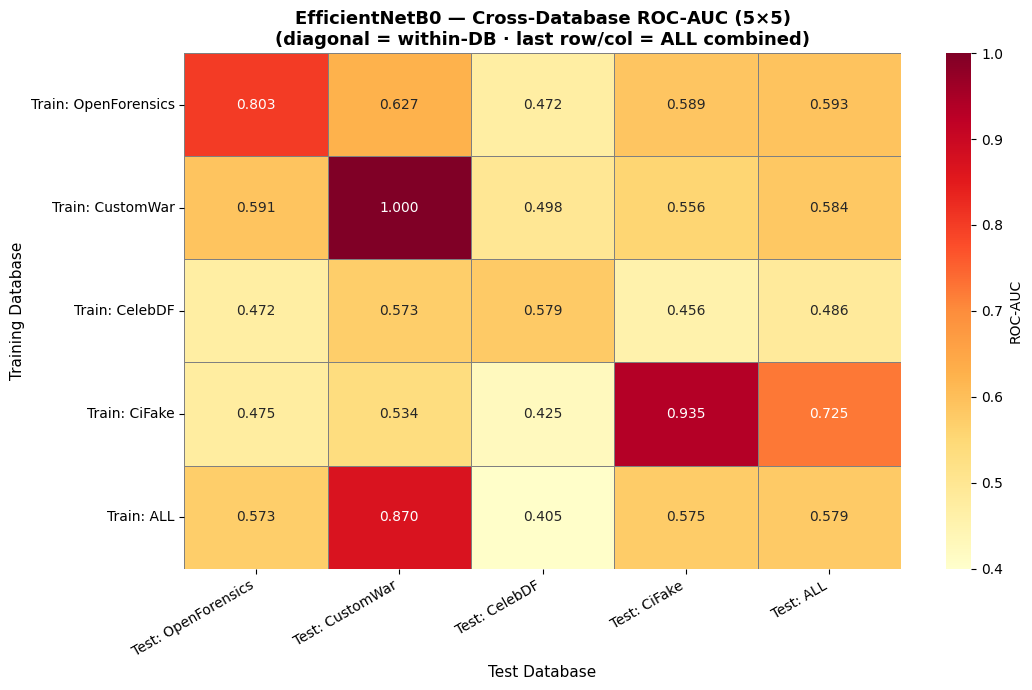

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_roc_auc.png

ROC-AUC Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.803074         0.626905       0.472309      0.589354   0.593282
Train: CustomWar                 0.591346         0.999850       0.497949      0.556231   0.583937
Train: CelebDF                   0.472126         0.573266       0.579349      0.455906   0.486372
Train: CiFake                    0.475404         0.534141       0.424678      0.935039   0.725452
Train: ALL                       0.572721         0.870304       0.404814      0.574624   0.579085



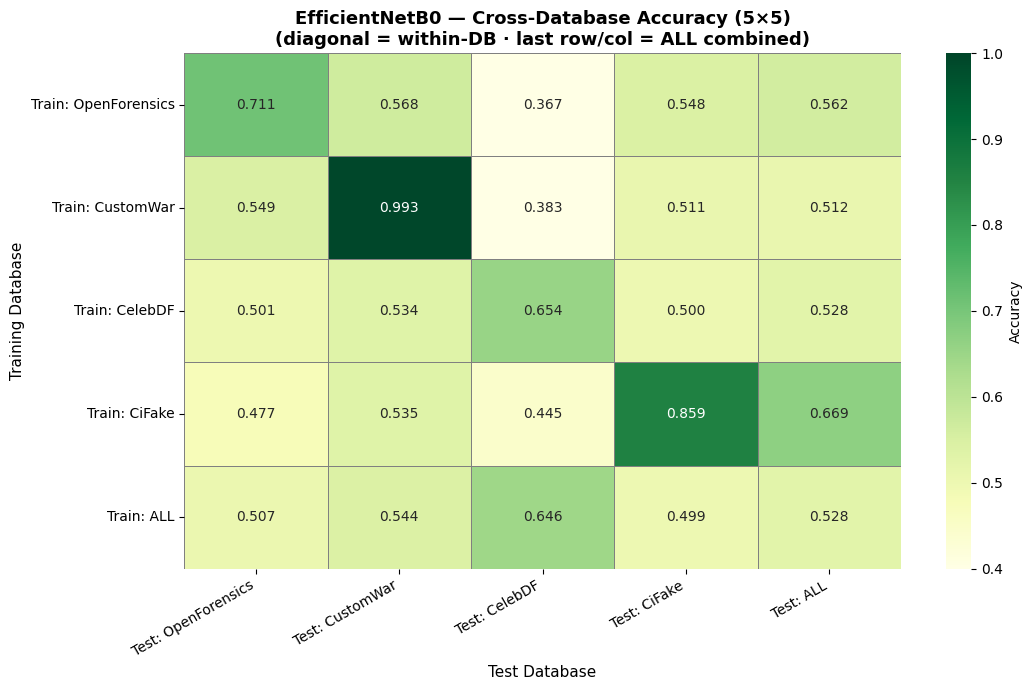

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_accuracy.png

Accuracy Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.711417         0.568332       0.366836       0.54755   0.562138
Train: CustomWar                 0.548647         0.993402       0.383273       0.51110   0.512191
Train: CelebDF                   0.500963         0.534402       0.653818       0.50005   0.528462
Train: CiFake                    0.477029         0.535344       0.444655       0.85850   0.669319
Train: ALL                       0.506923         0.543827       0.645673       0.49885   0.528333



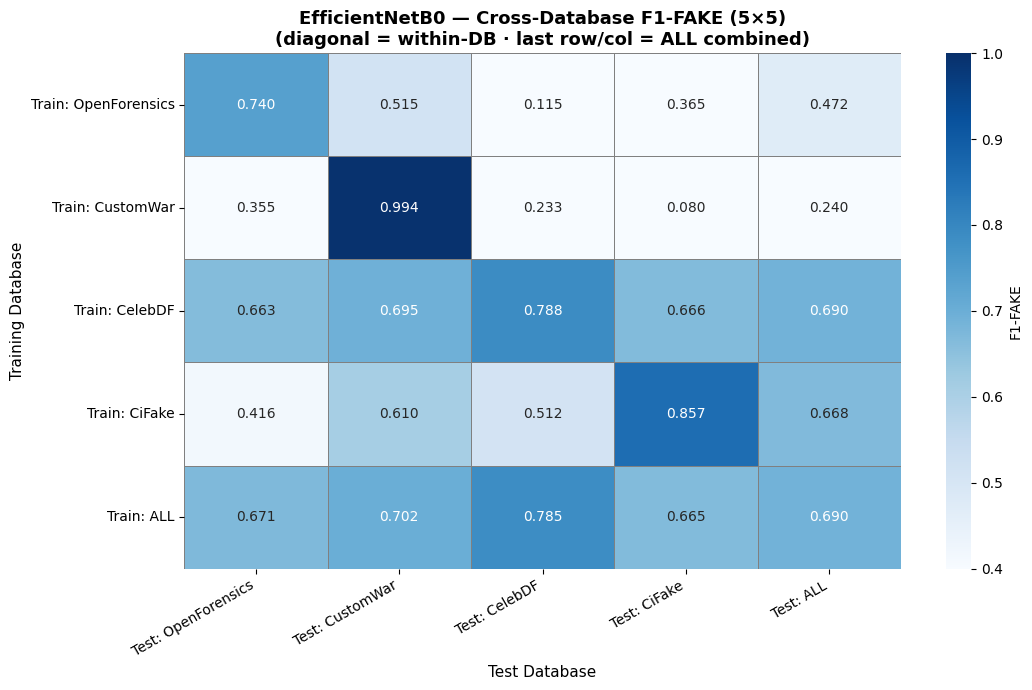

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_f1_fake.png

F1-FAKE Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.739681         0.514831       0.114704      0.365472   0.472013
Train: CustomWar                 0.355422         0.993886       0.232718      0.080497   0.240327
Train: CelebDF                   0.663284         0.694685       0.788407      0.666333   0.689550
Train: CiFake                    0.415856         0.609660       0.512264      0.857114   0.667770
Train: ALL                       0.670547         0.701970       0.784653      0.664928   0.690384



In [10]:
# Cell 10
# Cross-database ROC-AUC results heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

axis_names = list(DATABASES.keys()) + ['ALL']

for metric_key, metric_label, cmap in [
    ('roc_auc',  'ROC-AUC',  'YlOrRd'),
    ('accuracy', 'Accuracy', 'YlGn'),
    ('f1_fake',  'F1-FAKE',  'Blues'),
]:
    available = [d for d in axis_names if d in all_results]
    matrix = [
        [all_results[tr].get(te, {}).get(metric_key, float('nan')) for te in axis_names]
        for tr in available
    ]
    df = pd.DataFrame(
        matrix,
        index=[f'Train: {d}' for d in available],
        columns=[f'Test: {d}' for d in axis_names]
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.heatmap(
        df.astype(float), annot=True, fmt='.3f',
        cmap=cmap, vmin=0.40, vmax=1.00, ax=ax,
        linewidths=0.5, linecolor='gray',
        cbar_kws={'label': metric_label}
    )
    ax.set_title(
        f'EfficientNetB0 — Cross-Database {metric_label} (5×5)\n'
        '(diagonal = within-DB · last row/col = ALL combined)',
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel('Training Database', fontsize=11)
    ax.set_xlabel('Test Database',     fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'cross_db_{metric_key}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {fig_path}')
    print(f'\n{metric_label} Matrix:')
    print(df.to_string())
    print()

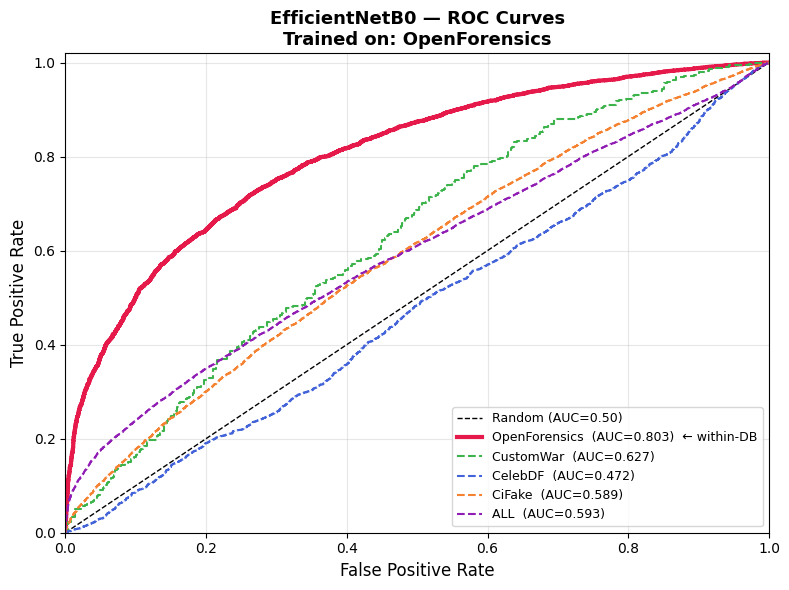

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/roc_curves_OpenForensics.png



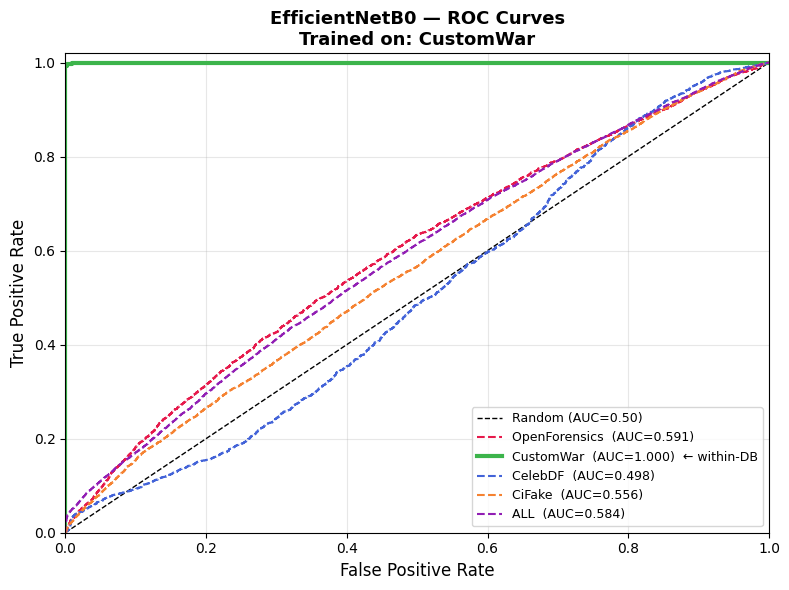

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/roc_curves_CustomWar.png



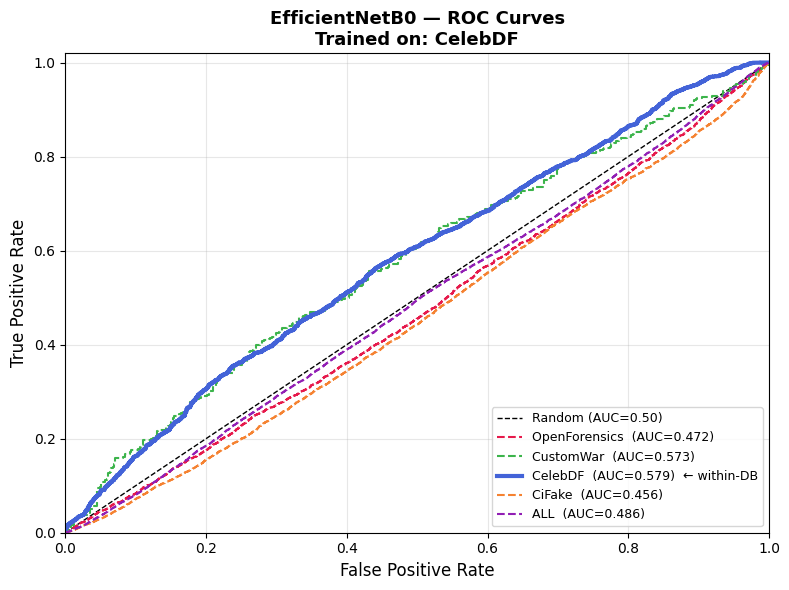

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/roc_curves_CelebDF.png



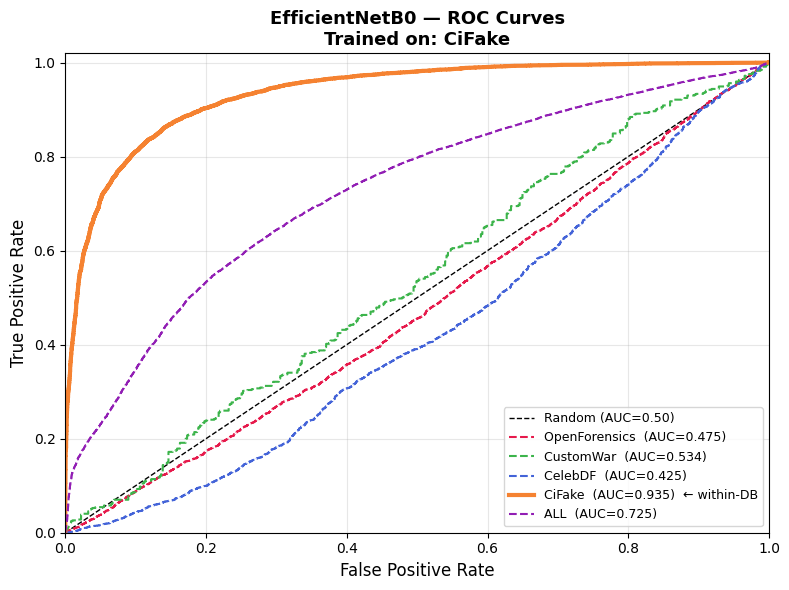

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/roc_curves_CiFake.png



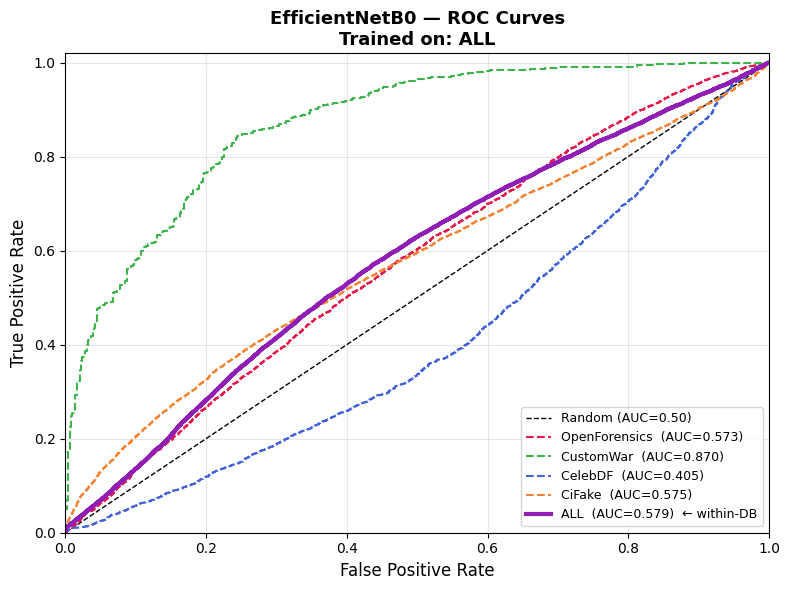

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/roc_curves_ALL.png



In [11]:
# Cell 11
# ROC curves for all train/test pairs
# One figure per training target (5 total).
# Each figure shows 5 ROC curves — one per test database.
# Within-DB curve is highlighted with a thicker solid line.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
import os

axis_names = list(DATABASES.keys()) + ['ALL']
TEST_COLORS = {
    db: c for db, c in zip(
        axis_names,
        ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    )
}

for train_target in axis_names:
    if train_target not in all_preds:
        print(f'[SKIP] No predictions for train={train_target}')
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')

    for test_target in axis_names:
        if test_target not in all_preds.get(train_target, {}):
            continue
        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_prob = np.array(all_preds[train_target][test_target]['y_prob'])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val   = all_results[train_target][test_target]['roc_auc']
        is_within = (train_target == test_target)
        label     = f'{test_target}  (AUC={auc_val:.3f})'
        if is_within:
            label += '  ← within-DB'
        ax.plot(fpr, tpr,
                color=TEST_COLORS.get(test_target, 'gray'),
                lw=3.0 if is_within else 1.5,
                ls='-'  if is_within else '--',
                label=label)

    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'EfficientNetB0 — ROC Curves\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'roc_curves_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

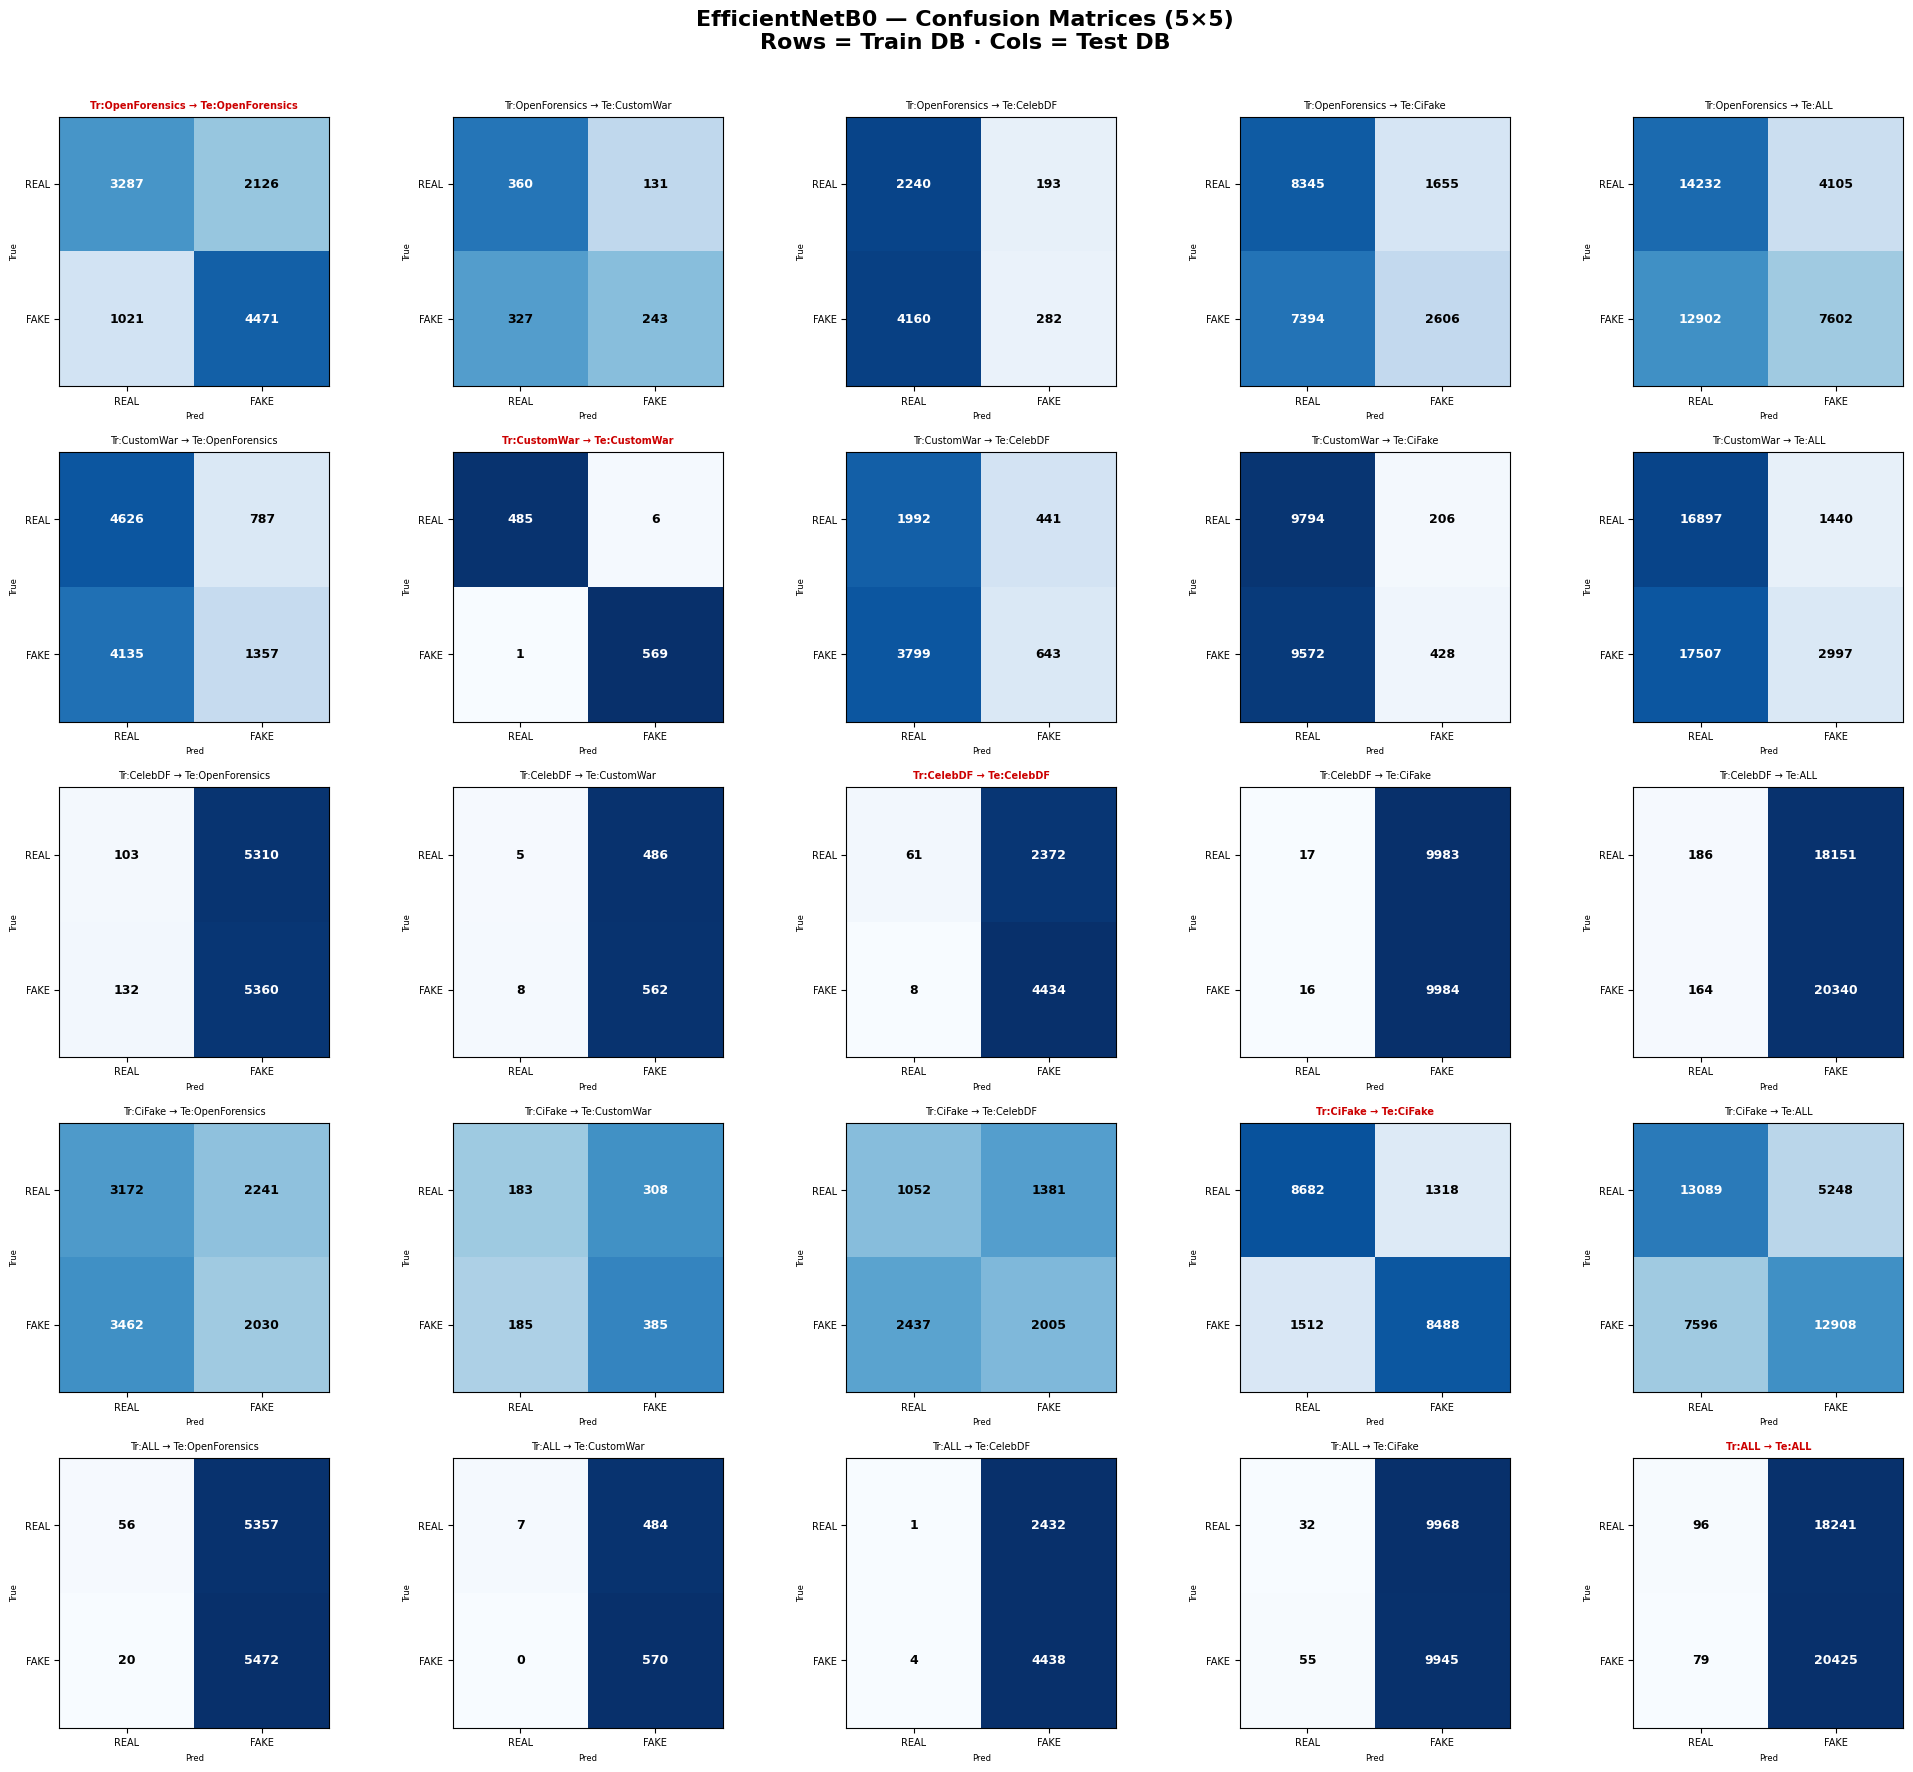

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/confusion_matrices_5x5.png


In [12]:
# Cell 12
# Confusion matrix grid (5x5)
# One confusion matrix per (train, test) pair — 25 total in a grid.
# Diagonal = within-DB (highlighted red title).
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os

axis_names = list(DATABASES.keys()) + ['ALL']
n = len(axis_names)

fig, axes = plt.subplots(n, n, figsize=(4 * n, 3.5 * n))
fig.suptitle('EfficientNetB0 — Confusion Matrices (5×5)\nRows = Train DB · Cols = Test DB',
             fontsize=16, fontweight='bold', y=1.01)

for r, train_target in enumerate(axis_names):
    for c, test_target in enumerate(axis_names):
        ax = axes[r][c]
        if (train_target not in all_preds or
                test_target not in all_preds.get(train_target, {})):
            ax.axis('off')
            ax.set_title(f'Tr:{train_target}\nTe:{test_target}', fontsize=7)
            continue

        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_pred = (np.array(all_preds[train_target][test_target]['y_prob']) >=
                  all_results[train_target][test_target].get('threshold', 0.5)).astype(int)
        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['REAL', 'FAKE'], fontsize=7)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['REAL', 'FAKE'], fontsize=7)
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)
        is_within = (train_target == test_target)
        ax.set_title(f'Tr:{train_target} → Te:{test_target}',
                     fontsize=7,
                     color='#cc0000' if is_within else 'black',
                     fontweight='bold' if is_within else 'normal')
        ax.set_ylabel('True', fontsize=6); ax.set_xlabel('Pred', fontsize=6)

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrices_5x5.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

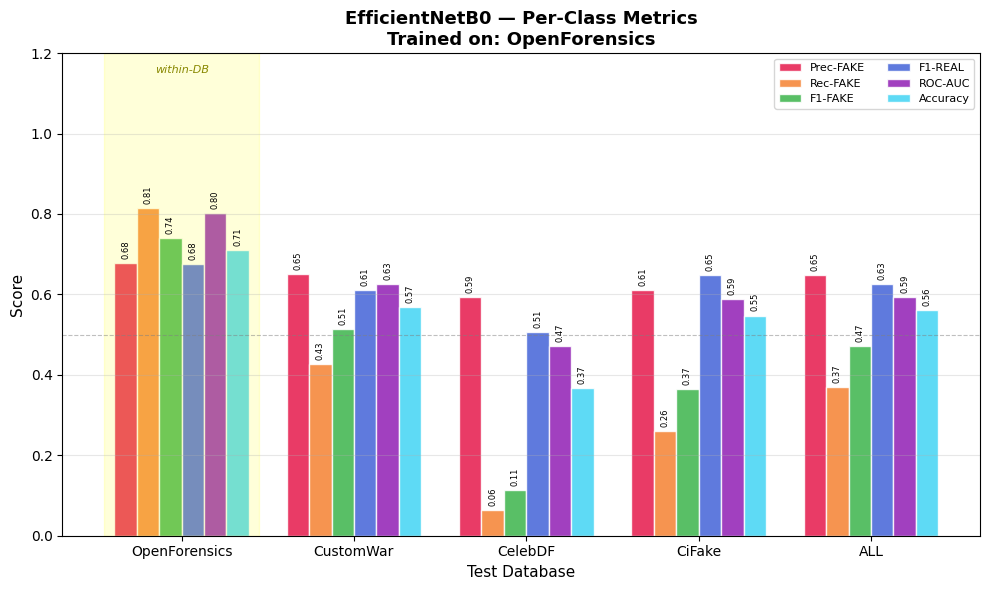

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/per_class_metrics_OpenForensics.png



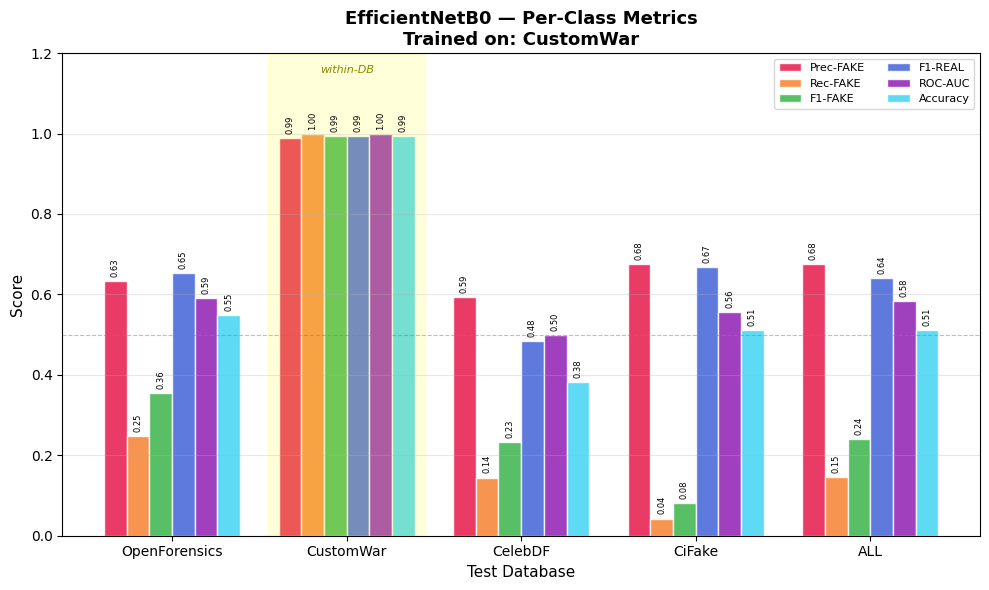

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/per_class_metrics_CustomWar.png



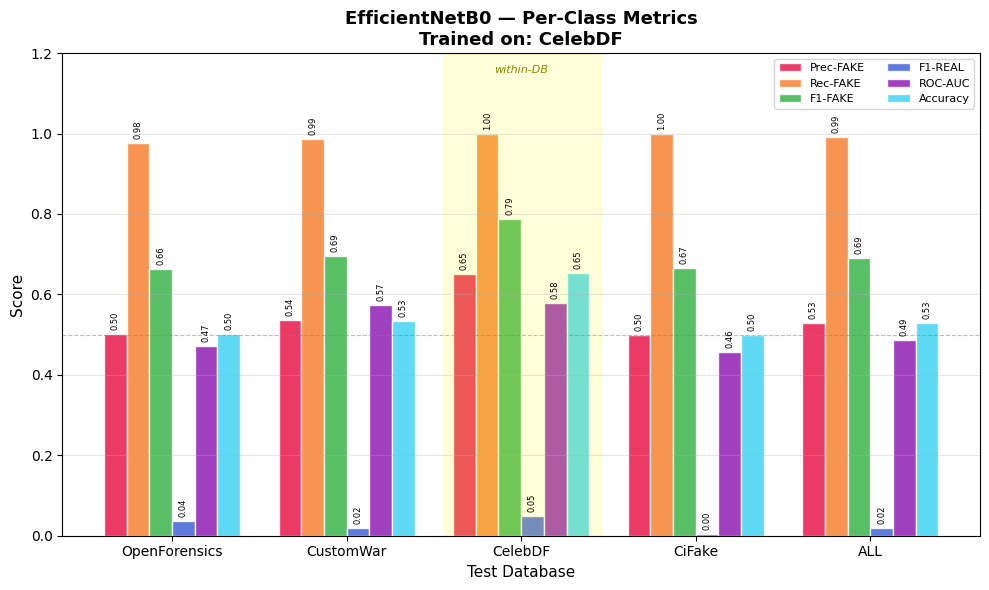

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/per_class_metrics_CelebDF.png



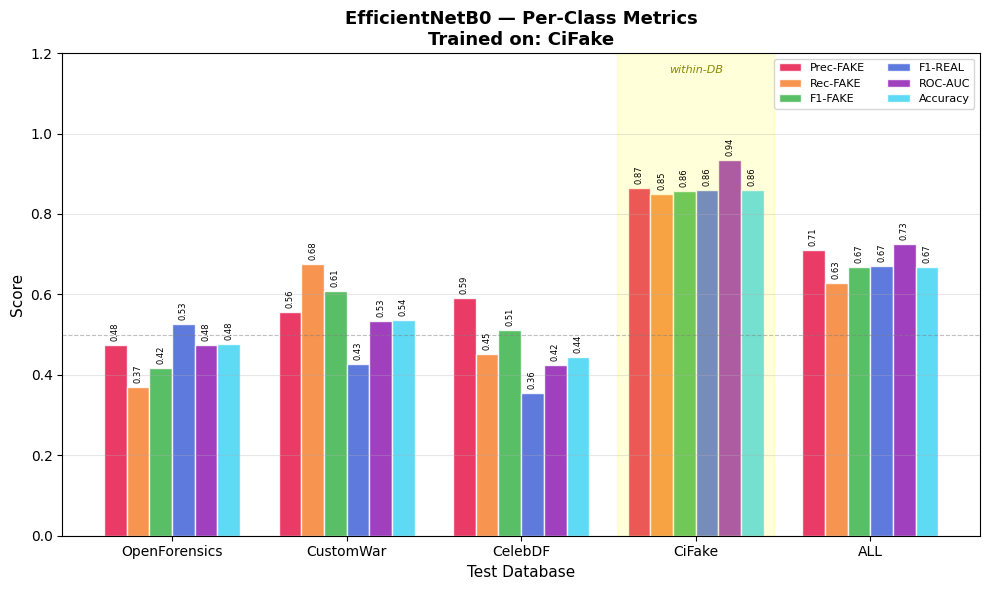

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/per_class_metrics_CiFake.png



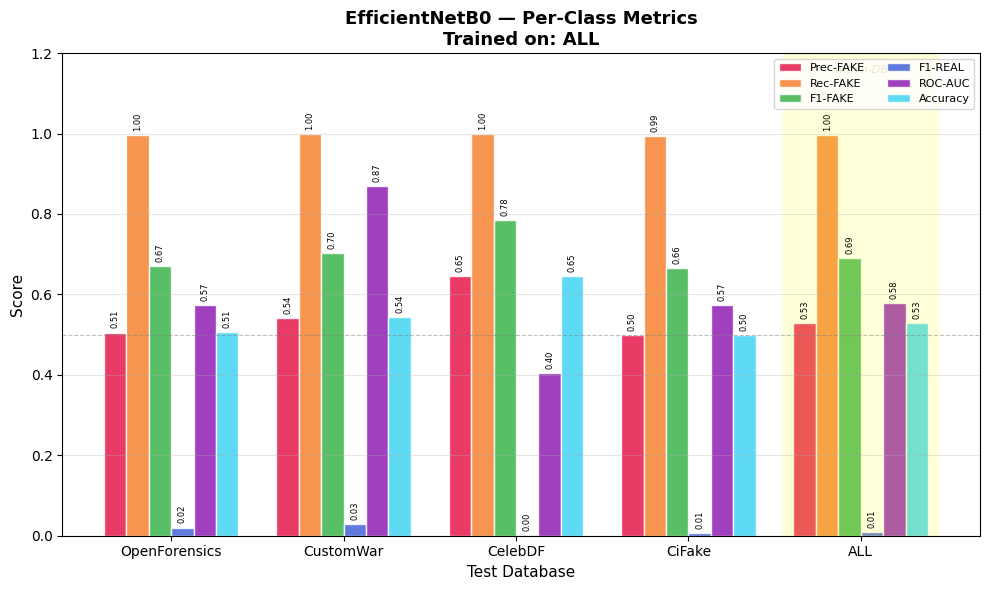

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/per_class_metrics_ALL.png



In [13]:
# Cell 13
# Per-class metrics bar chart
# For each training target: grouped bars showing Precision, Recall, F1 FAKE,
# F1 REAL, ROC-AUC, Accuracy across all test databases.
# Within-DB group highlighted in yellow.
import matplotlib.pyplot as plt
import numpy as np
import os

axis_names = list(DATABASES.keys()) + ['ALL']

METRICS = [
    ('precision_fake', 'Prec-FAKE',  '#e6194b'),
    ('recall_fake',    'Rec-FAKE',   '#f58231'),
    ('f1_fake',        'F1-FAKE',    '#3cb44b'),
    ('f1_real',        'F1-REAL',    '#4363d8'),
    ('roc_auc',        'ROC-AUC',    '#911eb4'),
    ('accuracy',       'Accuracy',   '#42d4f4'),
]

for train_target in axis_names:
    if train_target not in all_results:
        continue
    test_dbs  = [t for t in axis_names if t in all_results[train_target]]
    n_tests   = len(test_dbs)
    n_metrics = len(METRICS)
    x         = np.arange(n_tests)
    bar_w     = 0.13
    offsets   = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_tests * 2), 6))

    for i, (key, label, color) in enumerate(METRICS):
        values = [all_results[train_target][t].get(key, float('nan')) for t in test_dbs]
        bars   = ax.bar(x + offsets[i], values, bar_w,
                        label=label, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom',
                        fontsize=6, rotation=90)

    ax.set_xticks(x); ax.set_xticklabels(test_dbs, fontsize=10)
    ax.set_ylim(0, 1.20)
    ax.set_ylabel('Score', fontsize=11); ax.set_xlabel('Test Database', fontsize=11)
    ax.set_title(f'EfficientNetB0 — Per-Class Metrics\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)
    if train_target in test_dbs:
        idx = test_dbs.index(train_target)
        ax.axvspan(idx - 0.45, idx + 0.45, color='yellow', alpha=0.15)
        ax.text(idx, 1.15, 'within-DB', ha='center', fontsize=8,
                color='#888800', fontstyle='italic')

    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'per_class_metrics_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

In [14]:
# Cell 14
# Final sync of experiment artifacts to Google Drive
# Syncs ALL models, results (.pkl), CSV, and visualisation PNGs
# to Google Drive.  Runs after visualisations so every PNG is included.
import subprocess

gdrive_dest  = 'gdrive:deepfake_image_project/models/RealEyes_experiment/efficientnet'
print(f'Syncing {MODEL_DIR}')
print(f'     to {gdrive_dest} ...')

result = subprocess.run(
    ['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress', '--stats-one-line'],
    capture_output=False, text=True
)
if result.returncode == 0:
    print(f'\nGoogle Drive sync complete.')
    print(f'  All models, results, and visualisations are now on Drive.')
else:
    print(f'\nWARNING: rclone sync failed (exit {result.returncode}).')
    print(f'  Files are safe locally at {MODEL_DIR}')

Syncing /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet
     to gdrive:deepfake_image_project/models/RealEyes_experiment/efficientnet ...
634.011 KiB / 1.684 MiB, 37%, 0 B/s, ETA - (xfr#0/14)634.011 KiB / 1.684 MiB, 37%, 0 B/s, ETA - (xfr#0/14)920.885 KiB / 1.684 MiB, 53%, 633.930 KiB/s, ETA 1s (xfr#4/14)993.906 KiB / 1.684 MiB, 58%, 633.930 KiB/s, ETA 1s (xfr#7/14)1.400 MiB / 1.684 MiB, 83%, 496.912 KiB/s, ETA 0s (xfr#8/14)1.684 MiB / 1.684 MiB, 100%, 496.912 KiB/s, ETA 0s1.684 MiB / 1.684 MiB, 100%, 574.746 KiB/s, ETA 0s1.684 MiB / 1.684 MiB, 100%, 574.746 KiB/s, ETA 0s

Google Drive sync complete.
  All models, results, and visualisations are now on Drive.


In [15]:
# Cell 15
# Save results table to CSV/pickle
import pandas as pd

rows = []
for train_db, test_map in all_results.items():
    for test_db, metrics in test_map.items():
        rows.append({
            'model':    'efficientnet_b0',
            'train_db': train_db,
            'test_db':  test_db,
            **metrics,
        })

results_df = pd.DataFrame(rows)
csv_path   = os.path.join(MODEL_DIR, 'cross_db_results.csv')
results_df.to_csv(csv_path, index=False)

print('Results saved to:', csv_path)
print(f'Total rows: {len(results_df)}  (expected 25 for full 5×5)')
display(results_df)

Results saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/efficientnet/cross_db_results.csv
Total rows: 25  (expected 25 for full 5×5)


,model,train_db,test_db,accuracy,roc_auc,f1_fake,f1_real,precision_fake,recall_fake,threshold
0,efficientnet_b0,OpenForensics,OpenForensics,0.711417,0.803074,0.739681,0.676268,0.677732,0.814093,0.09
1,efficientnet_b0,OpenForensics,CustomWar,0.568332,0.626905,0.514831,0.611205,0.649733,0.426316,0.09
2,efficientnet_b0,OpenForensics,CelebDF,0.366836,0.472309,0.114704,0.507189,0.593684,0.063485,0.09
3,efficientnet_b0,OpenForensics,CiFake,0.547550,0.589354,0.365472,0.648432,0.611594,0.260600,0.09
4,efficientnet_b0,OpenForensics,ALL,0.562138,0.593282,0.472013,0.625981,0.649355,0.370757,0.09
5,efficientnet_b0,CustomWar,OpenForensics,0.548647,0.591346,0.355422,0.652744,0.632929,0.247087,0.51
6,efficientnet_b0,CustomWar,CustomWar,0.993402,0.999850,0.993886,0.992835,0.989565,0.998246,0.51
7,efficientnet_b0,CustomWar,CelebDF,0.383273,0.497949,0.232718,0.484436,0.593173,0.144755,0.51
8,efficientnet_b0,CustomWar,CiFake,0.511100,0.556231,0.080497,0.667030,0.675079,0.042800,0.51
9,efficientnet_b0,CustomWar,ALL,0.512191,0.583937,0.240327,0.640754,0.675456,0.146167,0.51


In [16]:
# Cell 16
# TensorBoard launch instructions
print('-' * 60)
print('  TENSORBOARD DASHBOARD')
print('-' * 60)
print()
print('1. On the SERVER terminal:')
print(f'   tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print()
print('2. On your LOCAL machine, open an SSH tunnel:')
print('   ssh -L 6006:localhost:6006 <your_user>@<server_ip>')
print()
print('3. Open in browser:  http://localhost:6006')
print()
print('TensorBoard log structure (now includes ALL run):')
print(f'  {TB_LOG_ROOT}/')
print(f'  └── {MODEL_NAME}/')
print(f'      ├── train_OpenForensics/')
print(f'      ├── train_CustomWar/')
print(f'      ├── train_CelebDF/')
print(f'      ├── train_CiFake/')
print(f'      ├── train_ALL/')
print(f'      └── cross_db_eval/')
print(f'          ├── train_OpenForensics__test_CustomWar/')
print(f'          ├── train_OpenForensics__test_ALL/')
print(f'          ├── train_ALL__test_OpenForensics/')
print(f'          └── ... (25 train→test pairs)')

------------------------------------------------------------
  TENSORBOARD DASHBOARD
------------------------------------------------------------

1. On the SERVER terminal:
   tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all

2. On your LOCAL machine, open an SSH tunnel:
   ssh -L 6006:localhost:6006 <your_user>@<server_ip>

3. Open in browser:  http://localhost:6006

TensorBoard log structure (now includes ALL run):
  /home/sceuser/RealEyes/tensorboard_logs/
  └── efficientnet/
      ├── train_OpenForensics/
      ├── train_CustomWar/
      ├── train_CelebDF/
      ├── train_CiFake/
      ├── train_ALL/
      └── cross_db_eval/
          ├── train_OpenForensics__test_CustomWar/
          ├── train_OpenForensics__test_ALL/
          ├── train_ALL__test_OpenForensics/
          └── ... (25 train→test pairs)
